#  <center> Problem Set 1 (MHC) <center>
<center> Spring 2025 <center>
<center> 3.C01/3.C51, 7.C01/7.C51, 10.C01/10.C51, 20.C01/20.C51 <center>
<center> Due: Monday, April 7, 2025 at 3:00 PM ET. <center>

<b>Name: Zach Pracher </b>

<b>Kerberos ID: zachprac</b>

### Instructions:

Put your code in the code blocks flagged with `############# Code ##########`.

Numerical answers yielded from running the code should be included in an Answer Block (see next cell).

We have provided print statements where numerical answers are expected.

Your answer should be contained in a variable which you defined either in the Answer Block or the Code Block.

When a qualitative answer is expected, place those comments as Markdown/Text cells; when asked for within Code blocks, you can write answer as code comments by placing a # before your answer.

Your Answer Block should look like the following:

In [245]:
########## Answer ############

ans = 2
print("My answer is: {}.".format(ans))

# My regressor over-fitted the training data, I need to add regularization

########## Answer ############

My answer is: 2.


## Imports

In [246]:
# import packages
import numpy as np
import sklearn
import pandas as pd
from sklearn.model_selection import train_test_split

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F

# metrics
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", category=ConvergenceWarning)
import torch
from tqdm import tqdm


# plotting style, you can choose your own parameters
import matplotlib

matplotlib.rcParams.update({'font.size': 15})
matplotlib.rc('lines', linewidth=3, color='g')
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams["xtick.major.size"] = 6
matplotlib.rcParams["ytick.major.size"] = 6
matplotlib.rcParams["ytick.major.width"] = 2
matplotlib.rcParams["xtick.major.width"] = 2
matplotlib.rcParams['text.usetex'] = False

In [247]:
# A helper function for students to produce plots
def plot_clf(model, X, y, title):

    '''
        A function to plot confusion matrix and ROC curve

        Args:
            model(classifier object): model object (e.g. RandomForestClassifier, LogisticRegression)
            X(np.array): feature set
            y(np.array): label set
            title(str): plot name

        Example Usage:
            plot_clf(model, X_test, y_test, "test")
    '''

    fig, [ax_roc, ax_conf] = plt.subplots(1, 2, figsize=(12, 6))
    fig.tight_layout()

    RocCurveDisplay.from_estimator(model, X, y, ax=ax_roc)
    ConfusionMatrixDisplay.from_estimator(model, X, y, ax=ax_conf)

    ax_roc.set_title('{} ROC'.format(title))
    ax_conf.set_title('{} Confusion Matrix'.format(title))

    plt.show()

## Grading guideline

- Didn't answer the question 0%
- Showed some attempts, but clearly didn't try enough: 25%
- Showed solid attempts (showed code) but does not answer the question directly: 50%
- Showed solid attempts and get the question wrong: 60-80%
- Showed solid attempts with some small mistakes: 80-90%
- Showed code and answered the questions correctly: 100%

# Overview:
In this PSET, you will:

* Learn the basics of processing your data and training a machine learning model with PyTorch:
    * Processing data, including exploring OHE vs. other featurization techniques
    * Formatting your data into a `Dataset` object and wrapping in a `DataLoader` instance
    * Implementation of a Multi-Layer Perception in `PyTorch`
    * Setting up a training and testing loop, and how to do evaluation
    * Using a GPU to accelerate training!
    * Find the best hyperparameters


* Learn how to build some simple architectures for **classification** and **regression**:
    * Train a logistic regression model with `scikit-learn` to _classify_ breast cancers based on metabolite abundance
    *  Train a random forest classifier on the same data
    * Train a MLP using `PyTorch` on the same data
    * Train a MLP with `PyTorch` to _regress_ binding affinities of antibodies from their sequences
    * Apply regularization techniques to avoid overfitting (L1 and L2)
    * Apply physical descriptor-based encoding to improve training performance


## Download required data

In [248]:
# for 1st set of tasks: binary classification
# TODO: update the datapaths
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_X.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_y.csv

# for 2nd set of tasks: regression of binding affinities
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/amino_acid.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/ba_train.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/ba_holdout.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/amino_acids.npy

--2025-04-07 16:26:31--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_X.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 469363 (458K) [text/plain]
Saving to: ‘breastcancer_X.csv.3’

breastcancer_X.csv. 100%[===================>] 458.36K  --.-KB/s    in 0.006s  

2025-04-07 16:26:31 (71.1 MB/s) - ‘breastcancer_X.csv.3’ saved [469363/469363]

--2025-04-07 16:26:31--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_y.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaitin

# Problem 1: Breast cancer classification from metabolite data

## 1.1 (5 points) Load and inspect the raw data

We have provided the code to load the dataset. Take a moment to understand what each line is doing. Briefly explain what each line of the code is doing by providing short comments below.

You will have to do it by yourself again in Problem 2.

In [249]:
p1_X = pd.read_csv("./breastcancer_X.csv", header='infer', index_col=0) # Load metabolites into CSV into a Pandas DataFrame
p1_y = pd.read_csv("./breastcancer_y.csv", header='infer', index_col=0) # Load breast cancer outcomes into a Pandas DataFrame

metabolite_name = p1_X.columns.tolist() # Compile a list of all unique metabolite names (stored in DataFrame columns)

p1_X = p1_X.values # Separate the metabolite values from the columns
p1_y = p1_y.values # Separate breast cancer outcomes

Report how many examples are in this dataset and the number of features for each data point.

In [250]:
########## Answer ############

N_samples = p1_X.shape[0]
N_features = p1_X.shape[1]

print("There are {} samples.".format(N_samples))
print("There are {} features per sample.".format(N_features))

########## Answer ############

There are 211 samples.
There are 128 features per sample.


## 1.2 (5 points) Generate train/test splits.
Generate and print the shapes of your four variables, `X_train`, `X_test`, `y_train`, and `y_test`, and ensure sure that the dimensions match your expectations.

In [251]:
########### Code #############

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(p1_X, p1_y, test_size=0.2, random_state=0)

########### Code #############

In [252]:
########## Answer ############

X_train_shape = X_train.shape
y_train_shape = y_train.shape
X_test_shape = X_test.shape
y_test_shape = y_test.shape


print("X_train shape: {}".format(X_train_shape))
print("y_train shape: {}".format(y_train_shape))

print("X_test shape: {}".format(X_test_shape))
print("y_test shape: {}".format(y_test_shape))

########## Answer ############

X_train shape: (168, 128)
y_train shape: (168, 1)
X_test shape: (43, 128)
y_test shape: (43, 1)


## 1.3 (5 points) Preprocess the data through scaling
Scale the dataset.

In [253]:
########### Code #############

scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

########### Code #############

Print the mean/variance for each transformed feature.

In [254]:
########## Answer ############

train_mean = X_train_scaled.mean(0)
train_variance = X_train_scaled.std(0) ** 2

test_mean = X_test_scaled.mean(0)
test_variance = X_test_scaled.std(0) ** 2

print("The means of the transformed feature train set are {}".format(train_mean))
print("The variances of the transformed feature train set are {}".format(train_variance))
print("The means of the transformed feature test set are {}".format(test_mean))
print("The variances of the transformed feature test set are {}".format(test_variance))

########## Answer ############

The means of the transformed feature train set are [ 2.47718512e-15  6.47630098e-16  7.92818966e-16  3.66770106e-17
  9.12629760e-16  4.66888433e-16  6.77182351e-16 -1.67855148e-16
  6.87611344e-16 -1.26238306e-15  2.70947286e-17 -4.73166480e-16
  2.80199144e-16  6.03446278e-16 -1.69606392e-15 -5.79562853e-16
 -7.89712211e-17 -2.31957311e-16 -5.20417043e-16 -1.12343997e-16
 -4.24924646e-16  5.74936923e-16  2.61034580e-16 -5.66345912e-16
 -3.48927236e-16 -6.21196216e-17  3.72717730e-16  1.17829027e-15
 -6.74063979e-16  1.65872607e-16 -7.87068823e-16  2.63347545e-16
  1.62105779e-15 -4.08155652e-16  3.24475896e-16  1.17795985e-15
  2.66982204e-16 -5.93771064e-16  3.50248930e-16 -1.35985799e-15
  1.21843673e-15  7.53365624e-16  1.02695630e-15 -1.77685247e-15
 -7.98964070e-16  2.24027146e-16 -5.54781089e-16  1.01109597e-16
 -2.33939852e-16  1.78676518e-16  1.73274093e-15  1.62568371e-16
 -3.37031990e-16  3.32406060e-16 -9.80697005e-16 -2.55086957e-16
  5.28677631e-18 -1.00448750e-16 -1.510


Q: Discuss the importance of not fitting the scaler transform on both train & test; why the transformed mean / variance between X_test_scaled & X_train_scaled may not be the same; and why this difference is potentially heartening.

#######################

We know that the mean and variance of both the training and test sets are about 0 and 1, respectively, but the X_test_scaled and X_train_scaled aren't exactly the same (this is the same for Y). This indicates that the scaler transform wasn't too overfit to the training data.

If we fit on both X_train and X_test, we might lose information about the differences in the distributions between our train and test datasets, which would indicate that our train/test split had biases.

#######################

## 1.4 (10 points) Training a logistic regression classifier with `scikit-learn`

`scikit-learn` has many handy simple machine learning frameworks that make it relatively simple to train, cross-validate, and tune a machine learning model that does not need to be heavily customized.


Below, train and evaluate a Logistic Regression model.

In [255]:
########### Code #############

model = sklearn.linear_model.LogisticRegression()
model.fit(X_train_scaled, y_train)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train_scaled)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

########### Code #############

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Report the AUC for both the train and test datasets.

In [256]:
########## Answer ############

print("The training AUC score is {:.3f}".format(train_auc) )
print("The testing AUC score is {:.3f}".format(test_auc) )

########## Answer ############

The training AUC score is 1.000
The testing AUC score is 0.998


Generate plots for the confusion matrices and the ROC curve for both training and testing. Please use the `plot_clf` function defined above.

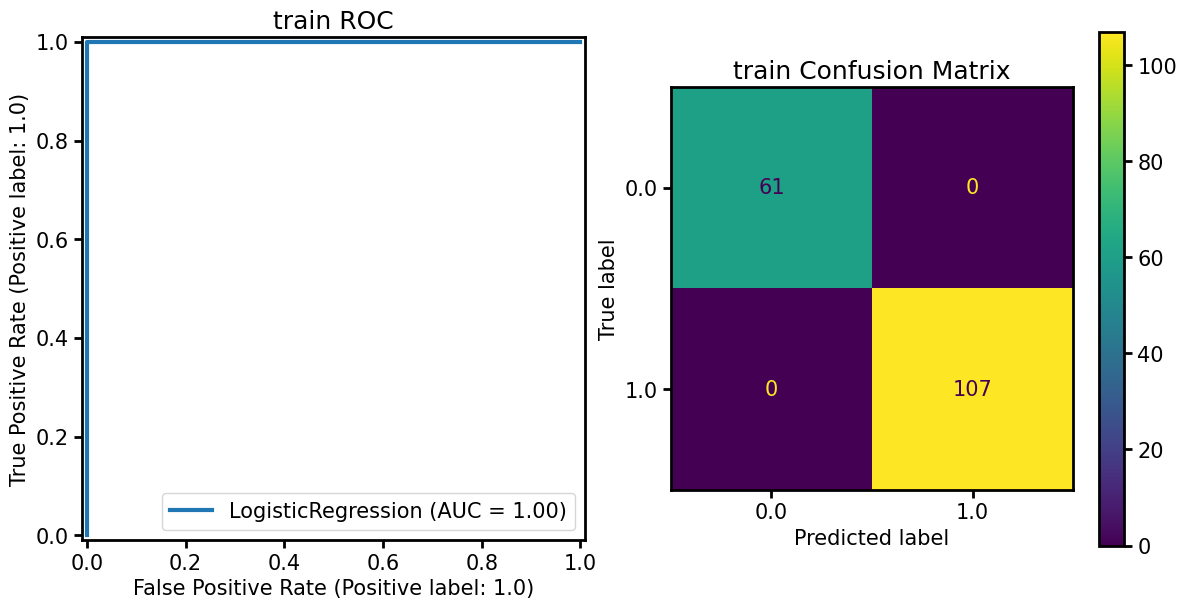

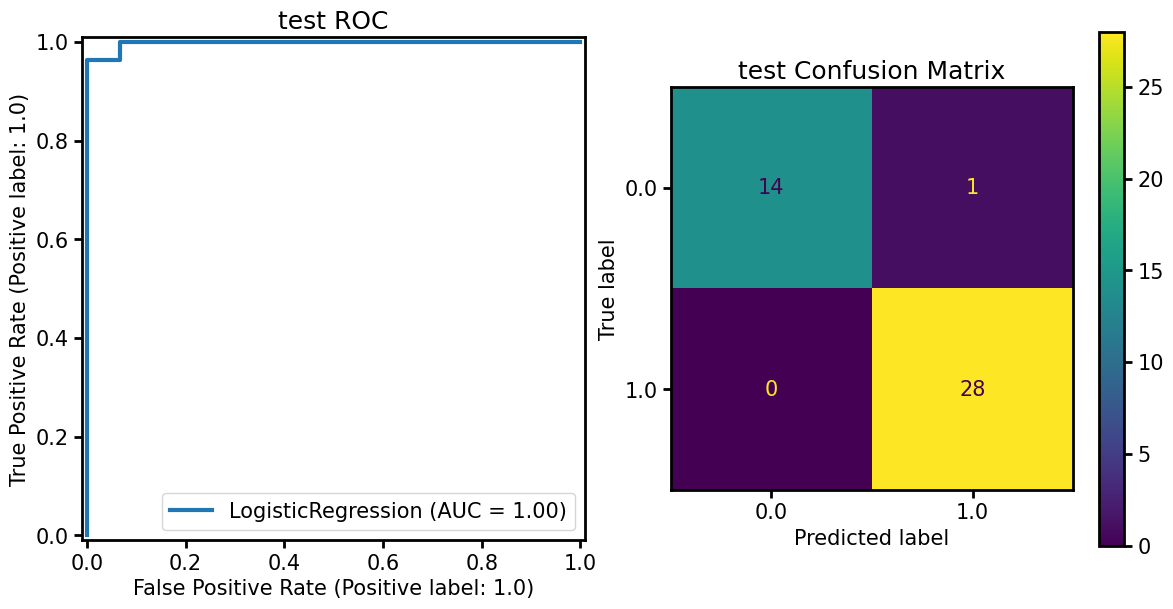

In [257]:
########### Code #############

plot_clf(model, X_train_scaled, y_train, "train")
plot_clf(model, X_test_scaled, y_test, "test")

########### Code #############

Generate a plot of the model coefficients' distribution using `plt.hist`.

(array([ 3.,  3., 10., 13., 30., 36., 17., 10.,  3.,  3.]),
 array([-0.63243751, -0.50809299, -0.38374848, -0.25940396, -0.13505945,
        -0.01071493,  0.11362959,  0.2379741 ,  0.36231862,  0.48666313,
         0.61100765]),
 <BarContainer object of 10 artists>)

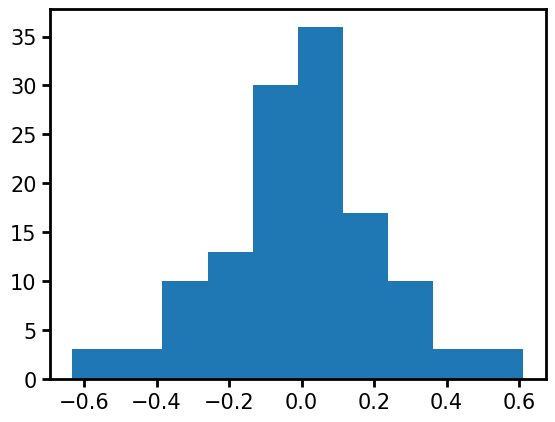

In [258]:
########### Code #############

matplotlib.pyplot.hist(model.coef_[0])

########### Code #############

## 1.5 (5 points) Introduce L1 regularization
Modify the LogisticRegression call made to run L1-regularized logistic regression.

In [259]:
########### Code #############

model_L1 = sklearn.linear_model.LogisticRegression(penalty="l1", solver='saga')
model_L1.fit(X_train_scaled, y_train)

train_auc = roc_auc_score(y_train, model_L1.predict(X_train_scaled))
test_auc = roc_auc_score(y_test, model_L1.predict(X_test_scaled))

########### Code #############

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Report the ROC-AUC score.

In [260]:
########## Answer ############


print("The training AUC score is {:.2f}".format(train_auc) )
print("The testing AUC score is {:.2f}".format(test_auc) )

########## Answer ############

The training AUC score is 0.99
The testing AUC score is 1.00


Correspondingly, generate the new confusion matrix and ROC curve.

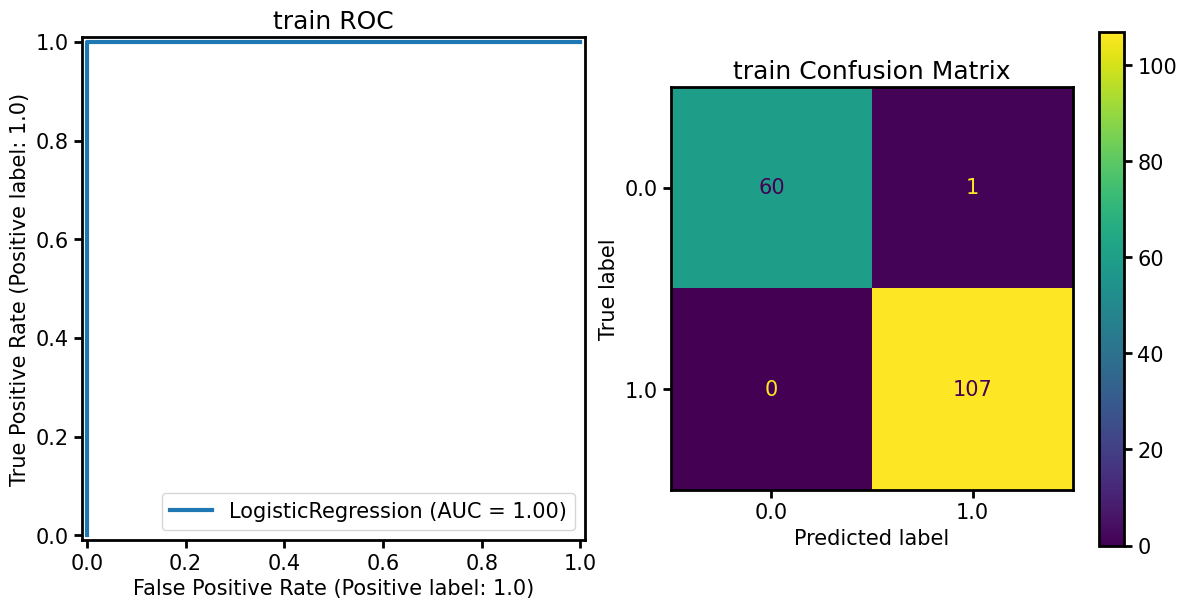

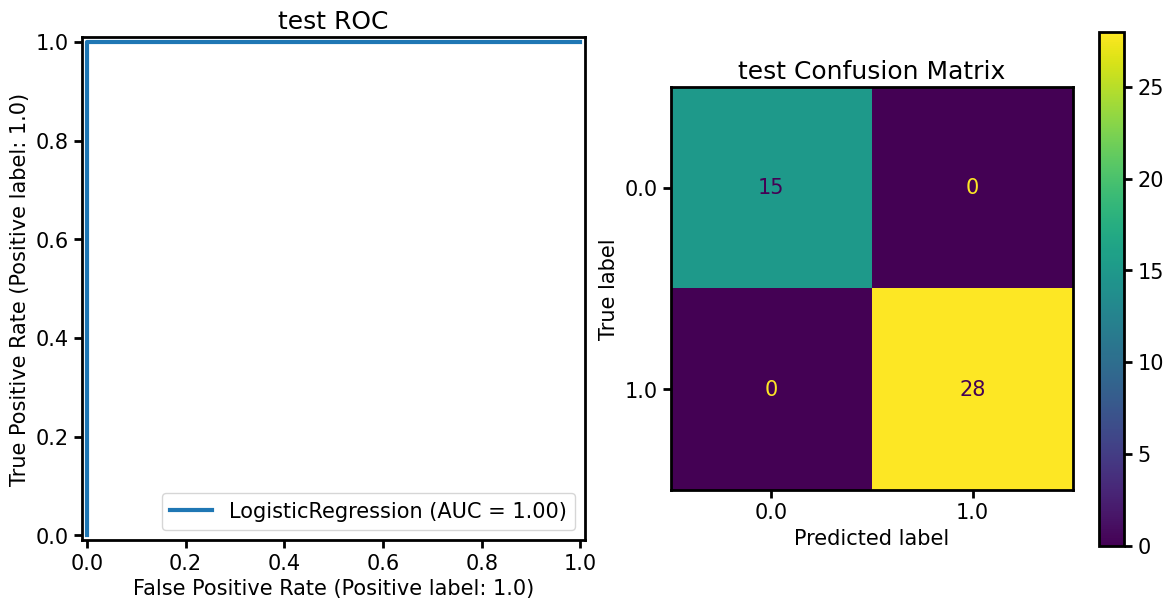

In [261]:
########### Code #############

plot_clf(model_L1, X_train_scaled, y_train, "train")
plot_clf(model_L1, X_test_scaled, y_test, "test")

########### Code #############

Plot the new distribution of model coefficients.

(array([ 1.,  3.,  3.,  6., 93., 11.,  7.,  1.,  1.,  2.]),
 array([-0.85158262, -0.68077441, -0.50996621, -0.339158  , -0.16834979,
         0.00245842,  0.17326663,  0.34407484,  0.51488304,  0.68569125,
         0.85649946]),
 <BarContainer object of 10 artists>)

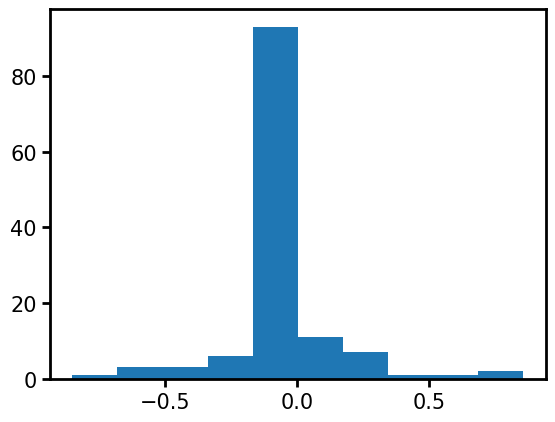

In [262]:
########### Code #############

matplotlib.pyplot.hist(model_L1.coef_[0])

########### Code #############

Comment on the histogram you obtained, by comparing it to the one generated from the unregularized model's coefficients.

Your answer here

## 1.6  (optional +2.5 points) Connect model coefficients back to metabolites

Code to identify the top 5 metabolites that positively correlated the most with positive diagnosis.

In [263]:
########### Code #############

# Retrieve coefficients for the final model
coeffs = model.coef_[0]

# Find indices for the largest 5 parameters (i.e. most weighted for positive diagnosis)
indys = np.argsort(coeffs)[-5:]

# Retrieve the metabolites from the original list
metabolites = [metabolite_name[i] for i in indys]

########### Code #############

Report the metabolites you identified.

In [264]:
########## Answer ############

print("The top 5 metabolites are {}".format(", ".join(metabolites)) )

########## Answer ############

The top 5 metabolites are Serine, à-Hydroxyisobutyric acid, 1,2-dimethylpropanol, L-Homoserine, 2-Butenedioic acid


## 1.7 (5 points) Hyperparameter tuning the regularization parameter
Scan over the following regularization values `C=[0.01, 1, 5, 10]` (in `scikit-learn`, the regularization parameter `C` is inversely related to the regularization strength) and report which one yields the best performance (with the AUROC metric) on the train dataset. What is its performance on the test data?

In [265]:
########### Code #############

C_values = [0.01, 1, 5, 10]
best_value = None
best_metric = 0

for C in C_values:
  model_c = sklearn.linear_model.LogisticRegression(penalty="l1", solver='saga', C=C)
  model_c.fit(X_train_scaled, y_train)

  train_auc = roc_auc_score(y_train, model_c.predict(X_train_scaled))
  test_auc = roc_auc_score(y_test, model_c.predict(X_test_scaled))

  ## Used train_auc here because the
  if test_auc > best_metric:
    best_metric = test_auc
    best_value = C

########### Code #############

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [266]:
########### Answer #############

print(f"Best value: C = {best_value}")
# Performance on test AUC:
print("The hyperparameterized model's test AUC score is {:.2f}".format(test_auc) )

########### Answer #############

Best value: C = 1
The hyperparameterized model's test AUC score is 0.97


The model performed best with C=1, and had an AUC score of 0.97.

## 1.8 (5 points) Training a random forest classifier with `scikit-learn`

To minimize the variance of our method to reduce error arising from epistemic error (that is, from a set of limited data), we may often look to train multiple copies of a machine learning model, i.e., an _ensemble_ machine learning method.

Here, train a Random Forest classifier, which is an ensemble of decision trees. Random Forests, empirically, work really well on tabular data, but can be known to overfit easily. To mitigate this concern, also perform cross validation.

In [267]:
########### Code #############
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


scaler = sklearn.preprocessing.StandardScaler() # fill this in (reusing your scaler implementation from 1.3)
model = RandomForestClassifier(max_depth=2, n_estimators=20) # fill this in
pipeline = Pipeline([('scaler', scaler), ('model', model)])

# Now call cross_val_score() and feed it: your pipeline as the estimator
# and your data (p1_X & p1_y) letting cross_val_score() handle the test / train split for you.

scores = cross_val_score(pipeline, p1_X, p1_y, scoring='roc_auc') # Default is 5-fold cross validation

########### Code #############

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

Report the cross-validated ROC-AUC score.

In [268]:
########## Answer ############

mean = scores.mean()
std = scores.std()

print("The mean of CV scores is {:.2f}".format(mean) )
print("The std of CV scores is {:.2f}".format(std) )

########## Answer ############

The mean of CV scores is 0.99
The std of CV scores is 0.02


# Problem 2: Training a Multi-Layer Perceptron (MLP) to predict binding affinities
## 2.1: (5 points) Encoding the data

For this second task, we will utilize peptide sequence data to predict their binding affinities. Before we can build a model, we need to process the data by one-hot encoding the peptides based on their amino acids.

Generate the X matrix and y vector from processing `binding_df_train` and `binding_df_test` appropriately (do not run any inference on `binding_df_test` until Part 2.5, but it's helpful to process it the same way here for consistency). Hint: Note that the one-hot encoding we perform should still give us a 2D matrix of `n_samples` x `n_features`, but now `n_features` will be different from the number of features originally.

In [269]:
binding_df_train = pd.read_csv("ba_train.csv") # Read in the dataset
binding_df_test = pd.read_csv("ba_holdout.csv") # Read in the holdout dataset
amino_acids = np.load('amino_acids.npy') # Read all amino acids

# Your code to featurize amino acids
########### Code #############

# Just to visualize and have in mind.
print(binding_df_train.head())

# Featurize each dataset


## LabelBinarizer version for submission
def featurize_AA(AA_seq, bin):
  split = [a for a in AA_seq] # Manually split the string into a list
  return bin.transform(split).flatten() # Apply the transform (using all 20 AA classes) to the list of strings representing the peptide

## One-liner for simple encoding without preprocessing.LabelBinarizer()

def featurize_OL(AA_seq):
  return np.array([amino_acids == aa for aa in AA_seq]).astype(int)

def featurize_dataset(data):
  peps = data['Peptide'].values # Retrieve each peptide
  y = data['Binding Affinity'].values # These will n-dimensional numpy arrays, no further modification needed.

  # Featurze amino acids for each peptide
  lb = preprocessing.LabelBinarizer().fit(amino_acids) # Create the binarizer, using all 20 AA classes so the samples are comparable.
  X = np.array([featurize_AA(seq, lb) for seq in peps]) # Apply the binarizer and featurizer to each peptide sequence, output as np array

  return X, y

X_train, y_train = featurize_dataset(binding_df_train)
X_test, y_test = featurize_dataset(binding_df_test)

N_samples = X_train.shape[0]
N_features = X_train.shape[1]
N_feat_vals = 2
########### Code #############

   Unnamed: 0    Peptide  Binding Affinity MHC Molecule  Peptide Length
0         345  AEDLADHHV          0.084687   HLA-B15:17               9
1         451  AEGVVAFLI          0.084687   HLA-B15:17               9
2        1065  AKATGRYNL          0.084687   HLA-B15:17               9
3        1102  AKYEICLEK          0.084687   HLA-B15:17               9
4        1200  ALFDRPAFK          0.084687   HLA-B15:17               9


Report the number of samples, number of features, and the number of possible values for one (not yet one-hot-encoded) feature you might have.

In [270]:
########## Answer ############

print("There are {} samples.".format(N_samples))
print("There are {} features per sample.".format(N_features))
print("There are {} possible values for one feature.".format(N_feat_vals))

########## Answer ############

There are 1226 samples.
There are 180 features per sample.
There are 2 possible values for one feature.


## Check GPU usage

In [271]:
# Check if your GPU is requested successfully or not
assert torch.cuda.device_count() != 0

To work with GPU-accelerated training, we need to use `PyTorch`'s `Tensor` objects, which can help us manage CPU vs. GPU usage.

Demonstrate moving this sample tensor to and from the GPU.

In [272]:
numpy_sample = np.zeros((3, 5))
tensor_sample = torch.Tensor(numpy_sample)
print(tensor_sample.device)

###
tensor_sample = tensor_sample.to('cuda')
print(tensor_sample.device)
tensor_sample = tensor_sample.to('cpu')
print(tensor_sample.device)


###

cpu
cuda:0
cpu


## Build Datasets and DataLoaders in PyTorch

Below, we provide you with an example of a `Dataset` instance, the `SequenceDataset` class, to format your data.

Note that tensors are not moved onto the GPU at initialization or inside `__getitem__`; GPU memory is typically far more limited than CPU-available memory. To prevent out-of-memory errors, we typically minimize the amount of data on the GPU at any time. During `.forward()`, the easiest way to do this is by only putting one batch at a time on the GPU.

In [273]:
# Generate dataset
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(np.array(X))  # store X as a pytorch Tensor
        self.y = torch.Tensor(np.array(y))  # store y as a pytorch Tensor
        self.len=len(self.X)                # number of samples in the data

    def __getitem__(self, index):
        return self.X[index], self.y[index] # get the appropriate item

    def __len__(self):
        return self.len

Now, we use the `Dataset` object to make train, validation, and test `SequenceDataset` objects, then wrap each in a `DataLoader` object. Here are some handy arguments you can use to format your `DataLoader`:
* `batch_size`: the number of examples that your model will see in one minibatch during one forward/backward call.
* `shuffle`: whether or not to shuffle your data between epochs; if it is set to True, then each epoch's batches will be different in identity (training should always have this set to True; for debugging or other reasons, you may wish to also have it true for validation and or test).
* `num_workers`: useful for when you have a lot of data to load in when making a batch; this allows you to multiprocess batch formation before they are executed on the GPU. it won't make much difference in this homework, but can be handy down the line :)

In [274]:
# Generate train/val splits and make dataloaders
X_subtrain, X_val, y_subtrain, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

train_data = SequenceDataset(X_subtrain, y_subtrain)
val_data = SequenceDataset(X_val, y_val)
test_data = SequenceDataset(X_test, y_test)

batch_size = 128
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

Run this cell to check that the DataLoaders work as expected.

In [275]:
# Check data shapes
for loader in [train_dataloader, val_dataloader, test_dataloader]:
    for index, batch in enumerate(loader):
        # Your batch returns a X, y stacked in a batch
        X_batch, y_batch = batch[0], batch[1]
        print(X_batch.shape, y_batch.shape)
    print()

torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([84, 180]) torch.Size([84])

torch.Size([128, 180]) torch.Size([128])
torch.Size([118, 180]) torch.Size([118])

torch.Size([128, 180]) torch.Size([128])
torch.Size([104, 180]) torch.Size([104])



There should be 8 training set batches (with one partial train set batch), 2 validation batches, and 2 test batches, with sizes shown above.

## 2.2 (10 points) Define the MLP in PyTorch

Look at the following code snippet to understand how the linear layer works in PyTorch. Take careful note of the dimensions of the input and output.

In [276]:
linear = torch.nn.Linear(2, 3)

input_tensor = torch.ones((4, 2))
output_tensor = linear(input_tensor)

print(f"Input tensor of shape {input_tensor.shape}:\n{input_tensor} \nOutput tensor of shape {output_tensor.shape}:\n{output_tensor}")

Input tensor of shape torch.Size([4, 2]):
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) 
Output tensor of shape torch.Size([4, 3]):
tensor([[0.8519, 0.4105, 1.2108],
        [0.8519, 0.4105, 1.2108],
        [0.8519, 0.4105, 1.2108],
        [0.8519, 0.4105, 1.2108]], grad_fn=<AddmmBackward0>)


Look at the following code snippet to understand how the ReLU layer works in PyTorch (the Tanh layer is similar). Take careful note of the dimensions of the input and output.

In [277]:
relu = torch.nn.ReLU()

input_tensor = torch.ones((4, 2))
output_tensor = relu(input_tensor)

print(f"Input tensor of shape {input_tensor.shape}:\n{input_tensor} \nOutput tensor of shape {output_tensor.shape}:\n{output_tensor}")

Input tensor of shape torch.Size([4, 2]):
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) 
Output tensor of shape torch.Size([4, 2]):
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])


Look at the following code snippet to understand how to stack layers with the Sequential module.

In [278]:
layer1 = torch.nn.Linear(2, 3)
layer2 = torch.nn.Linear(3, 4)

sequential = torch.nn.Sequential(layer1, layer2)

input_tensor = torch.ones((5, 2))
output_tensor = sequential(input_tensor)

print(f"Input tensor of shape {input_tensor.shape}:\n{input_tensor} \nOutput tensor of shape {output_tensor.shape}:\n{output_tensor}")

Input tensor of shape torch.Size([5, 2]):
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) 
Output tensor of shape torch.Size([5, 4]):
tensor([[-0.0783, -0.0748,  0.1491,  0.0743],
        [-0.0783, -0.0748,  0.1491,  0.0743],
        [-0.0783, -0.0748,  0.1491,  0.0743],
        [-0.0783, -0.0748,  0.1491,  0.0743],
        [-0.0783, -0.0748,  0.1491,  0.0743]], grad_fn=<AddmmBackward0>)


Build your MLP within the following torch.nn.Module object.

In [279]:
########### Code #############
class BindingMLP(torch.nn.Module):
    def __init__(self, in_features=None, layers=None, activation=None, learning_rate=0.1, weight_decay=0.01):
        # You may either modify the above __init__ call to either take in hyperparameters as keyword arguments,
        # or hard-code them below. If you want to do hyperparameter search, then modifying to take in
        # keyword arguments is recommended.
        super().__init__()

        ########### Code #############

        # Implement your code here
        self.layers = layers

        self.model = nn.Sequential(nn.Linear(in_features, layers[0]),
                                   activation,
                                   nn.Linear(layers[0], layers[1]),
                                   activation,
                                   nn.Linear(layers[1], layers[2]),
                                   activation,
                                   nn.Linear(layers[2], 1))
        ########### Code #############
    def forward(self, x):
        x = self.model(x)

        return x

########### Code #############

## 2.3 (10 points) Implement functions for training and testing

We define your device, model, and epochs; fill in the optimizer and loss function. For the optimizer, use an L2 weight of 0.01 and the Adam optimizer.

In [280]:
########### Code #############

# device to train on
device = 'cuda:0'
# define your model
## ZACH N.B. The input features is 180, indicating we should FLATTEN the input 20x9 vectors for each sample.
model = BindingMLP(in_features=180, layers=(512, 256, 128), activation=nn.ReLU()).to(device)

# define your optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.01) # Fill in
# define your loss function
loss_fn = nn.MSELoss() # Fill in

# define number of epochs
epochs = 250

########### Code #############

Implement your training and validation loops here.

In [281]:
########### Code #############

def train(model, dataloader, optimizer, loss_fn, device):

    '''
    A function train on the entire dataset for one epoch.

    Args:
        model (torch.nn.Module): your model from before
        dataloader (torch.utils.data.DataLoader): DataLoader object for the train data
        optimizer (torch.optim.Optimizer(()): optimizer object to interface gradient calculation and optimization
        device (str): Your device (usually 'cuda:0' for your GPU)

    Returns:
        float: loss averaged over all the batches
    '''

    epoch_loss = []
    model.train() # Set model to training mode

    for batch in dataloader:
        # Clear the gradients for each minibatch
        optimizer.zero_grad()

        # Retreive inputs (X) and ground truths (y)
        X, y = batch
        #print(f"Input X shape: {X.shape}\nFlattened X shape: {flat.shape} ")
        X = X.to(device)
        #print(f"True Y shape: {y.shape}")
        y = y.to(device)

        # train your model on each batch here
        y_pred = model(X).squeeze(1)
        #print(f"Predicted y shape: {y_pred.shape}\n")

        ########### Code #############
        # Compute loss, store it, then find gradient
        batch_loss = loss_fn(y_pred, y)
        epoch_loss.append(batch_loss.item())
        batch_loss.backward()

        # Adjust weights
        optimizer.step()

        ########### Code #############
    epoch_mean = sum(epoch_loss) / len(epoch_loss)
    #print(f"Epoch Loss type: {type(epoch_loss)}")
    #print(f"Sum Type: {type(tot_loss)}")
    #print(f"Len Type: {type(len(epoch_loss))}")
    #print(f"Avg: {epoch_mean}, Type: {type(epoch_mean)}")
    return epoch_mean



def validate(model, dataloader, loss_fn, device):

    '''
    A function validate on the validation dataset for one epoch.

    Args:
        model (torch.nn.Module): your model for before
        dataloader (torch.utils.data.DataLoader): DataLoader object for the validation data
        device (str): Your device (usually 'cuda:0' for your GPU)

    Returns:
        float: loss averaged over all the batches

    '''

    val_loss = []
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        for batch in dataloader:

            X, y = batch
            #print(f"Input X shape: {X.shape}\nFlattened X shape: {flat.shape} ")
            X = X.to(device)
            #print(f"True Y shape: {y.shape}")
            y = y.to(device)

            # train your model on each batch here
            y_pred = model(X).squeeze(1)
            #print(f"Predicted y shape: {y_pred.shape}\n")

            ########### Code #############
            # Compute loss, store it, then find gradient
            batch_loss = loss_fn(y_pred, y)
            val_loss.append(batch_loss.item())
            ########### Code #############
    epoch_mean = sum(val_loss) / len(val_loss)
    return epoch_mean
########### Code #############

Train and validate your model.

In [282]:
########### Code ###########
val_loss_curve = []
train_loss_curve = []

def update(progress_bar, train_loss, val_loss):
    progress_bar.set_postfix({"train_loss": train_loss, "val_loss": val_loss})

progress_bar = tqdm(range(epochs)) # this wraps your iteration in a handy progress bar to track any metrics.

for epoch in progress_bar:

    # Train your model on training data
    train_loss = train(model, train_dataloader, optimizer, loss_fn=loss_fn, device=device)
    #print(f"Train Loss type: {type(train_loss)}")
    # Validate your model on validation data
    val_loss = validate(model, val_dataloader, loss_fn=loss_fn, device=device)
    #print(f"Val Loss type: {type(val_loss)}")
    # Record train and loss performance
    train_loss_curve.append(train_loss)
    val_loss_curve.append(val_loss)

    update(progress_bar, train_loss, val_loss)
########### Code ###########

100%|██████████| 250/250 [00:06<00:00, 39.60it/s, train_loss=0.00711, val_loss=0.0274]


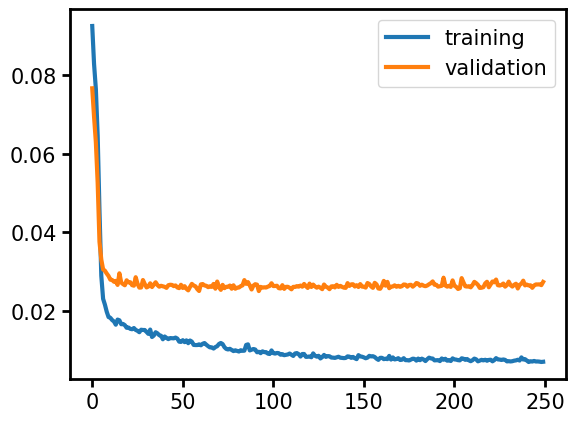

In [283]:
plt.plot(train_loss_curve, label="training")
plt.plot(val_loss_curve, label="validation")
plt.legend()

Multi-Layer Perceptron training R^2 score: 0.92
Multi-Layer Perceptron testing R^2 score: 0.64


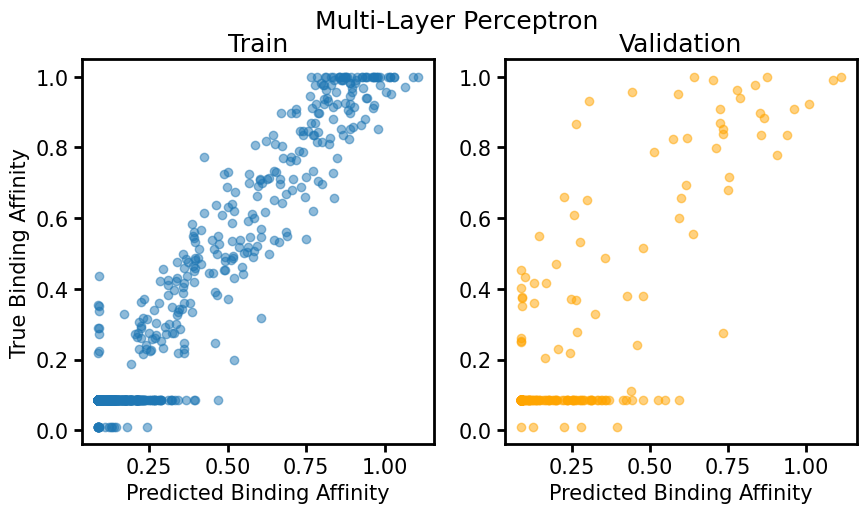

In [284]:
########### Code #############
from sklearn.metrics import r2_score

def batch_predict(dataset):
  tensors = []
  for batch in dataset:
    X, y = batch
    flat = torch.flatten(X, start_dim=1)
    #print(f"Input X shape: {X.shape}\nFlattened X shape: {flat.shape} ")
    X = flat.to(device)

    # train your model on each batch here
    y_pred = model(X).squeeze(1)
    tensors.append(y_pred)

    #print(f"Flattend X Shape: {X.shape} \t\t Predicted y shape: {y_pred.shape}")
  compiled = torch.cat(tensors)
  return compiled

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

yhat_train = model(torch.Tensor(X_subtrain).to(device))
yhat_val = model(torch.Tensor(X_val).to(device))

#yhat_train = batch_predict(train_dataloader) # Fill in
#yhat_val = batch_predict(val_dataloader) # Fill in

yhat_train = yhat_train.cpu().detach().numpy()
yhat_val = yhat_val.cpu().detach().numpy()
ax[0].scatter(yhat_train, y_subtrain, label='Train', alpha=0.5)
ax[1].scatter(yhat_val, y_val, label='Test', alpha=0.5, c='orange')

ax[0].set_ylabel("True Binding Affinity")
ax[0].set_xlabel("Predicted Binding Affinity")
ax[1].set_xlabel("Predicted Binding Affinity")
ax[0].set_title('Train')
ax[1].set_title('Validation')
fig.suptitle('Multi-Layer Perceptron')

print("Multi-Layer Perceptron training R^2 score: {:.2f}".format(r2_score(y_subtrain, yhat_train)))
print("Multi-Layer Perceptron testing R^2 score: {:.2f}".format((r2_score(y_val, yhat_val))))

########### Code #############

## 2.4 (5 points) (grad) Calculate model size

Calculate the total of number of parameters in your MLP model. What does the input hidden_layers_sizes = (512, 256, 128) mean?

In [285]:
########## Answer ############

total_params = sum(param.numel() for param in model.parameters())
print(total_params)
########## Answer ############

257025


#Output
The code above indicates our model has 257,025 parameters.
#Reasoning
Our input layer is 180 features, because we flattened a 9 x 20 matrix representing the 20 amino acids at 9 positions. Moving to a layer of 512 neurons, we should have (180 x 512) or 92,160 parameters. Conencting the 512- to 256-neuron layer, we get another (512 x 256) or 131,072 parameters. Connecting the 256- to 128-neuron layer, we get another 32,768 paramters, and then 128 weight parameters collapsing to the final prediction of binding affinity (128 x 1). This gives us a total of 256,000 weight parameters. We have 1 bias term per neuron, and we have (512+256+128+1) neurons, bringing us to a toal of 257,025 parameters, in agreement with the code above.



## 2.5 (5 points) Chemical Transferability of One-Hot Representations

Multi-Layer Perceptron testing R^2 score: 0.64
MLP Holdout R^2 score: 0.07


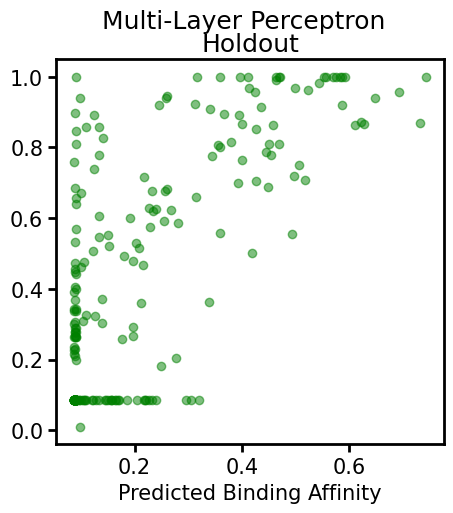

In [286]:
########### Code #############

# Load the holdout dataset which contains amino acids not seen in the training data
ba_holdout = pd.read_csv("ba_holdout.csv")

# Your code to preprocess data and predict on this holdout dataset, including a scatterplot of predictions

yhat_holdout = model(torch.Tensor(X_test).to(device))
yhat_holdout = yhat_holdout.cpu().detach().numpy()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

ax.scatter(yhat_holdout, y_test, label='Test', alpha=0.5, c='green')
ax.set_xlabel("Predicted Binding Affinity")
ax.set_title('Holdout')
fig.suptitle('Multi-Layer Perceptron')

print("Multi-Layer Perceptron testing R^2 score: {:.2f}".format((r2_score(y_val, yhat_val))))

print("MLP Holdout R^2 score: {:.2f}".format(r2_score(y_test, yhat_holdout)))
########### Code #############

Comment on your validation results and briefly explain.

The model does not generalize well, as we can see from the R^2 value of 0.08, which indicates that the predicted binding affinities do not correlate with the observed binding affinities for the held-out peptides. This demonstrates that One-Hot-Encoded peptides do not enable the model to learn generalizable relationships of protein properties and binding affinities for MHC (i.e. a useful latent space).

## 2.6 (10 points) (grad) Featurize amino acids with physical descriptors

In [304]:
########### Code #############
amino_acid_df = pd.read_csv("amino_acid.csv")
amino_acid_df = amino_acid_df.set_index('Amino Acids')

def phys_featurize(AA_seq):
  tot_props = []
  for aa in AA_seq:
    props = amino_acid_df.loc[aa]
    tot_props.append(props)
  return torch.Tensor(tot_props).flatten()

def phys_featurize_dataset(data):
  peps = data['Peptide'].values # Retrieve each peptide
  y = data['Binding Affinity'].values # These will n-dimensional numpy arrays, no further modification needed.

  # Featurze amino acids for each peptide
  lb = preprocessing.LabelBinarizer().fit(amino_acids) # Create the binarizer, using all 20 AA classes so the samples are comparable.
  X = np.array([phys_featurize(seq) for seq in peps]) # Apply the binarizer and featurizer to each peptide sequence, output as np array

  return X, y

## Featurize
X_train_f, y_train_f = phys_featurize_dataset(binding_df_train)
X_test_f, y_test_f = phys_featurize_dataset(binding_df_test)

## Scale the data, since now our features are continuous
scaler = preprocessing.StandardScaler()
X_train_f_s = scaler.fit_transform(X_train_f)
X_test_f_s = scaler.transform(X_test_f)

## Make train-test splits
X_subtrain_f, X_val_f, y_subtrain_f, y_val_f = train_test_split(X_train_f_s, y_train_f, test_size=0.2, random_state=0)

########### Code #############

<ipython-input-304-89538a6f25e4>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.Tensor(tot_props).flatten()
<ipython-input-304-89538a6f25e4>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.Tensor(tot_props).flatten()


In [305]:
########### Code #############
# new dataloaders needed
new_train_data = SequenceDataset(X_subtrain_f, y_subtrain_f)
new_train_dataloader = DataLoader(new_train_data, batch_size=batch_size, shuffle=True)

new_val_data = SequenceDataset(X_val_f, y_val_f)
new_val_dataloader = DataLoader(new_val_data, batch_size=batch_size, shuffle=True)
########### Code #############

In [306]:
########### Code #############

# device to train on
device = 'cuda:0'
# Define new model
new_model = BindingMLP(in_features=675, layers=(512, 256, 128), activation=nn.ReLU()).to(device)

# define your optimizer
optimizer = torch.optim.Adam(new_model.parameters(), lr=1e-3, weight_decay=0.01) # Fill in
# define your loss function
loss_fn = nn.MSELoss() # Fill in

# define number of epochs
epochs = 250

########### Code #############

In [307]:
########### Code ###########
val_loss_curve = []
train_loss_curve = []

def update(progress_bar, train_loss, val_loss):
    progress_bar.set_postfix({"train_loss": train_loss, "val_loss": val_loss})

progress_bar = tqdm(range(epochs)) # this wraps your iteration in a handy progress bar to track any metrics.

for epoch in progress_bar:

    # Train your model on training data
    train_loss = train(new_model, new_train_dataloader, optimizer, loss_fn=loss_fn, device=device)
    #print(f"Train Loss type: {type(train_loss)}")
    # Validate your model on validation data
    val_loss = validate(new_model, new_val_dataloader, loss_fn=loss_fn, device=device)
    #print(f"Val Loss type: {type(val_loss)}")
    # Record train and loss performance
    train_loss_curve.append(train_loss)
    val_loss_curve.append(val_loss)

    update(progress_bar, train_loss, val_loss)
########### Code ###########

100%|██████████| 250/250 [00:08<00:00, 30.30it/s, train_loss=0.00227, val_loss=0.025]


Retrained MLP Training R^2 score: 0.97
Retrained MLP Validation R^2 score: 0.67


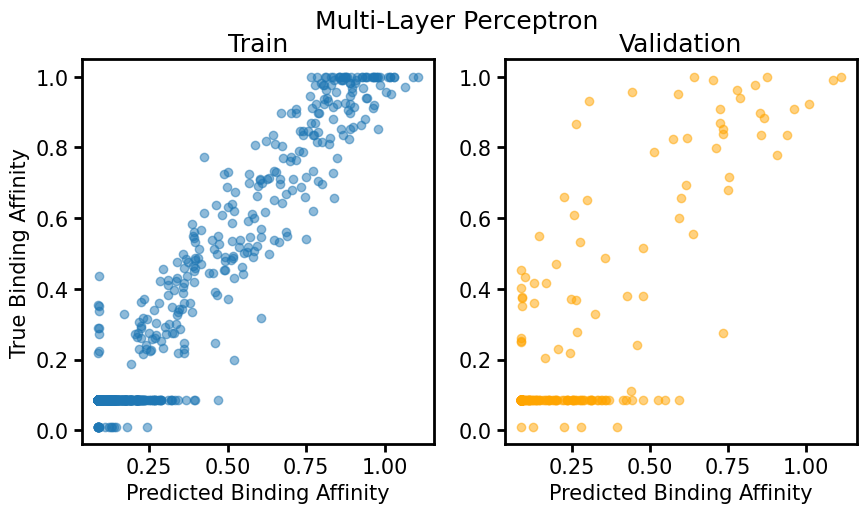

In [308]:
########### Code #############
from sklearn.metrics import r2_score

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

yhat_new_train = new_model(torch.Tensor(X_subtrain_f).to(device))
yhat_new_val = new_model(torch.Tensor(X_val_f).to(device))

yhat_new_train = yhat_new_train.cpu().detach().numpy()
yhat_new_val = yhat_new_val.cpu().detach().numpy()
ax[0].scatter(yhat_train, y_subtrain, label='Train', alpha=0.5)
ax[1].scatter(yhat_val, y_val, label='Test', alpha=0.5, c='orange')

ax[0].set_ylabel("True Binding Affinity")
ax[0].set_xlabel("Predicted Binding Affinity")
ax[1].set_xlabel("Predicted Binding Affinity")
ax[0].set_title('Train')
ax[1].set_title('Validation')
fig.suptitle('Multi-Layer Perceptron')

print("Retrained MLP Training R^2 score: {:.2f}".format(r2_score(y_subtrain_f, yhat_new_train)))
print("Retrained MLP Validation R^2 score: {:.2f}".format(r2_score(y_val_f, yhat_new_val)))

## 2.7 (10 points) (grad) Chemical transferability of Physical Descriptors

MLP holdout R^2 score: 0.33


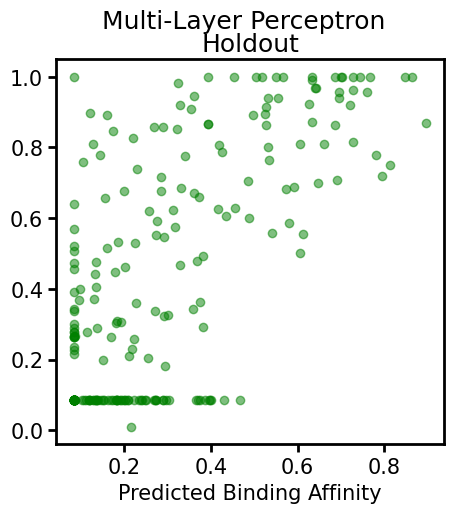

In [310]:
# Your code to preprocess data and predict on this holdout dataset, including a scatterplot of predictions

yhat_holdout_new = new_model(torch.Tensor(X_test_f_s).to(device)).squeeze(1)
yhat_holdout_new = yhat_holdout_new.cpu().detach().numpy()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

ax.scatter(yhat_holdout_new, y_test_f, label='Test', alpha=0.5, c='green')
ax.set_xlabel("Predicted Binding Affinity")
ax.set_title('Holdout')
fig.suptitle('Multi-Layer Perceptron')

print("MLP holdout R^2 score: {:.2f}".format(r2_score(y_test, yhat_holdout_new)))

Briefly comment on your holdout performance and explain why.

The R^2 value of 0.33 is significantly higher than it was for the One-Hot Encoding (which was 0.07)! This is likely because the physical parameters encoded by the VHSE and BLOSUM vectors are (closer to) direct determinants of the binding affinity, thus they enable the model to learn a generalizable latent space consisting of some combination of the physical properties, which more directly determine binding affinity. Furthermore, this means that the model will be better able to group together residues which are similar in physical properties but are encoded by distinct amino acids (e.g. differentiating the basic residues, K, R, and H), which the One-Hot Encoder would artificially separate.

You've reached the end! Upon completing your pset, note any collaborators or assistance from AI tools in a cell below; and submit to Gradescope [here](https://www.gradescope.com/courses/1011324/assignments/6007173/).